In [2]:
# import all the neccessary library

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# import dataset
df_video_game = pd.read_csv('Video Game Data Set.csv')
df_video_game.head(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [4]:
df_video_game.shape

(16598, 11)

In [5]:
df_video_game.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [6]:
df_video_game.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [7]:
# check for missing records in video_game dataframe

df_video_game.isnull().sum().sum()

329

In [8]:
# inspect columns containing missing values

df_video_game.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [9]:
df_video_game[['Year','Publisher']].any()

Year         True
Publisher    True
dtype: bool

In [10]:
# drop rows having null values

df_video_game = df_video_game.dropna(subset = ['Year','Publisher'])

In [11]:
# re-check to see eradication of null records 

df_video_game.isnull().sum()

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

In [12]:
# check for duplicate records

df_video_game.duplicated().sum()

0

In [13]:
# HOW HAS THE POPULARITY OF DIFFERENT GAMES GENRE EVOVLED OVER THE YEARS?

yearly_game_counts = df_video_game.groupby('Year')['Genre'].count().reset_index()

# rename columns for clarity
yearly_game_counts.columns = ['Year', 'count of Genre']
yearly_game_counts

,Year,count of Genre
0,1980.0,9
1,1981.0,46
2,1982.0,36
3,1983.0,17
4,1984.0,14
5,1985.0,14
6,1986.0,21
7,1987.0,16
8,1988.0,15
9,1989.0,17


In [14]:
df_video_game['Year'].unique()

array([2006., 1985., 2008., 2009., 1996., 1989., 1984., 2005., 1999.,
       2007., 2010., 2013., 2004., 1990., 1988., 2002., 2001., 2011.,
       1998., 2015., 2012., 2014., 1992., 1997., 1993., 1994., 1982.,
       2003., 1986., 2000., 1995., 2016., 1991., 1981., 1987., 1980.,
       1983., 2020., 2017.])

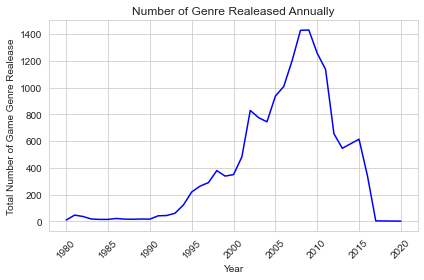

In [15]:
sns.set_style("whitegrid")
sns.lineplot(data=yearly_game_counts, x = 'Year', y = 'count of Genre', color='blue')

plt.xticks(rotation=45)

# Set plot labels and title
plt.xlabel('Year')
plt.ylabel('Total Number of Game Genre Realease')
plt.title('Number of Genre Realeased Annually')

# Display the plot
plt.tight_layout()
plt.show()

In [16]:
# WHICH GAMING PLATFORMS HAS BEEN THE MOST SUCCESSFUL BASED ON GLOBAL SALES?

gaming_platforms = df_video_game.groupby('Platform')['Global_Sales'].sum().reset_index()

# rename column for clarity
gaming_platforms.columns = ['Platform ', 'Total_Global_Sales']

gaming_platforms = gaming_platforms.sort_values('Total_Global_Sales', ascending = False).iloc[:8]
gaming_platforms

,Platform,Total_Global_Sales
16,PS2,1233.46
28,X360,969.60
17,PS3,949.35
26,Wii,909.81
4,DS,818.91
15,PS,727.39
6,GBA,305.62
19,PSP,291.71


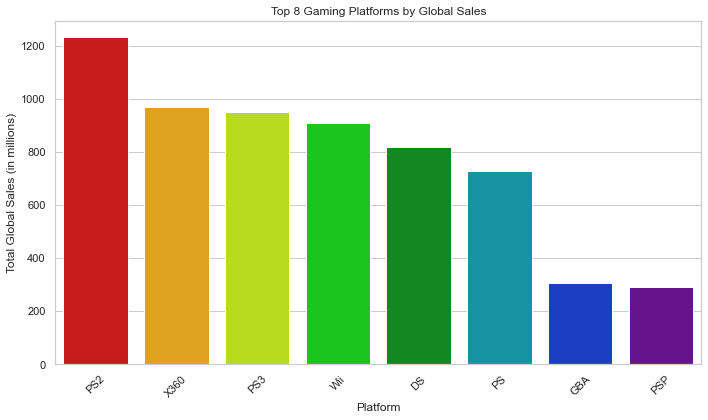

In [17]:
# Create a vertical bar plot using Seaborn
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")  # Set the style, optional

sns.barplot(x='Platform ', y='Total_Global_Sales', data=gaming_platforms, palette='nipy_spectral_r')

# Set plot labels and title
plt.xlabel('Platform')
plt.ylabel('Total Global Sales (in millions)')
plt.title('Top 8 Gaming Platforms by Global Sales')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display the plot
plt.tight_layout()
plt.show()


In [18]:
# WHICH PUBLISHER HAS THE HIGHEST AVERAGE GLOBAL SALES PER GAME?

# check for uniqie publisher
df_video_game['Publisher'].unique()

array(['Nintendo', 'Microsoft Game Studios', 'Take-Two Interactive',
       'Sony Computer Entertainment', 'Activision', 'Ubisoft',
       'Bethesda Softworks', 'Electronic Arts', 'Sega', 'SquareSoft',
       'Atari', '505 Games', 'Capcom', 'GT Interactive',
       'Konami Digital Entertainment',
       'Sony Computer Entertainment Europe', 'Square Enix', 'LucasArts',
       'Virgin Interactive', 'Warner Bros. Interactive Entertainment',
       'Universal Interactive', 'Eidos Interactive', 'RedOctane',
       'Vivendi Games', 'Enix Corporation', 'Namco Bandai Games',
       'Palcom', 'Hasbro Interactive', 'THQ', 'Fox Interactive',
       'Acclaim Entertainment', 'MTV Games', 'Disney Interactive Studios',
       'Majesco Entertainment', 'Codemasters', 'Red Orb', 'Level 5',
       'Arena Entertainment', 'Midway Games', 'JVC', 'Deep Silver',
       '989 Studios', 'NCSoft', 'UEP Systems', 'Parker Bros.', 'Maxis',
       'Imagic', 'Tecmo Koei', 'Valve Software', 'ASCII Entertainment',
     

In [19]:
# Calculate the average of 'Global_Sales' for each publisher combination
pub_Highest_avg_sales = df_video_game.groupby('Publisher')['Global_Sales'].mean().reset_index().iloc[:11]

# Sort the DataFrame by 'Global_Sales' in descending order and select the top 5 rows
pub_Highest_avg_sales = pub_Highest_avg_sales.sort_values('Global_Sales', ascending=False)

# rename column for simplicity and clarity
pub_Highest_avg_sales.columns = ['publisher','Average Global_Sales']

# Print the result
pub_Highest_avg_sales


,publisher,Average Global_Sales
10,989 Studios,0.951429
2,20th Century Fox Video Games,0.388000
9,989 Sports,0.380000
6,505 Games,0.291198
4,3DO,0.281111
3,2D Boy,0.040000
5,49Games,0.040000
0,10TACLE Studios,0.036667
1,1C Company,0.033333
7,5pb,0.026721


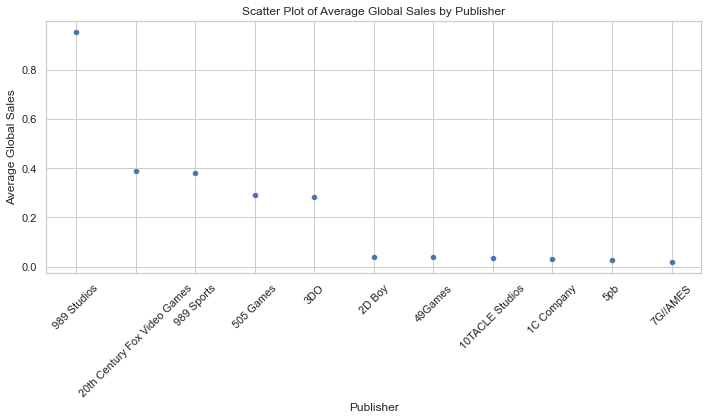

In [20]:
# Create a scatter plot using Seaborn
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")  # Set the style, optional

sns.scatterplot(x='publisher', y='Average Global_Sales', data=pub_Highest_avg_sales, palette='viridis')

# Set plot labels and title
plt.xlabel('Publisher')
plt.ylabel('Average Global Sales')
plt.title('Scatter Plot of Average Global Sales by Publisher')

# Rotate x-axis labels for better readability (optional)
plt.xticks(rotation=45)

# Display the plot
plt.tight_layout()
plt.show()


In [21]:
# HOW DO ANNUAL GAME SALES VARY BETWEEN DIFFERENT REGIONS (NORTH AMERICA,EUROPE,JAPAN & OTHERS) SPECIFICALLY FROM YEAR 2008 TO 2020

game_sales_in_regions = df_video_game.groupby('Year')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum().reset_index().iloc[28:]

# rename columns for clarity
game_sales_in_regions.columns = ['Year', 'Total_NA_Sales', 'Total_EU_Sales', 'Total_JP_Sales', 'Total_Other_Sales']
game_sales_in_regions

,Year,Total_NA_Sales,Total_EU_Sales,Total_JP_Sales,Total_Other_Sales
28,2008.0,351.44,184.40,60.26,82.39
29,2009.0,338.85,191.59,61.89,74.77
30,2010.0,304.24,176.57,59.49,59.90
31,2011.0,241.00,167.31,53.04,54.39
32,2012.0,154.93,118.76,51.74,37.82
33,2013.0,154.77,125.80,47.59,39.82
34,2014.0,131.97,125.63,39.46,40.02
35,2015.0,102.82,97.71,33.72,30.01
36,2016.0,22.66,26.76,13.67,7.75
37,2017.0,0.00,0.00,0.05,0.00


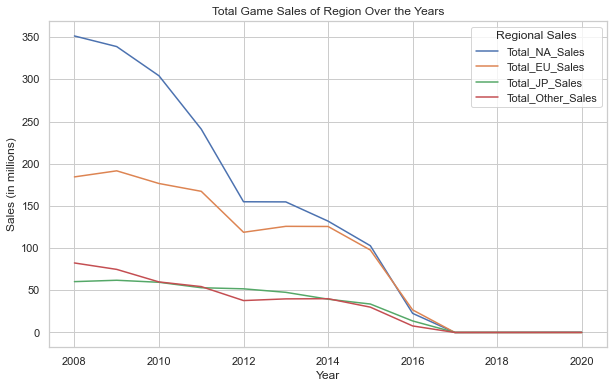

In [22]:
# Reshape the data using pd.melt
melted_data = pd.melt(
    game_sales_in_regions,
    id_vars=['Year'],
    value_vars=['Total_NA_Sales', 'Total_EU_Sales', 'Total_JP_Sales', 'Total_Other_Sales'],
    var_name='Region',
    value_name='Sales (in millions)'
)

plt.figure(figsize=(10, 6))

# Using Seaborn to create the stacked line plot
sns.lineplot(
    x='Year',
    y='Sales (in millions)',
    hue='Region',
    data=melted_data,
    ci=None  # To remove confidence intervals
)

# Set plot labels, legend and title
plt.xlabel('Year')
plt.ylabel('Sales (in millions)')
plt.title('Total Game Sales of Region Over the Years')
plt.legend(title='Regional Sales')
plt.show()


In [23]:
# WHAT ARE THE TOP 10 GAMES WITH THE HIGHEST GLOBAL SALES?


Top_10_games = df_video_game.nlargest(10, 'Global_Sales')[['Name','Global_Sales','Genre','Year']]
Top_10_games.reset_index(drop=True, inplace=True)
Top_10_games

,Name,Global_Sales,Genre,Year
0,Wii Sports,82.74,Sports,2006.0
1,Super Mario Bros.,40.24,Platform,1985.0
2,Mario Kart Wii,35.82,Racing,2008.0
3,Wii Sports Resort,33.00,Sports,2009.0
4,Pokemon Red/Pokemon Blue,31.37,Role-Playing,1996.0
5,Tetris,30.26,Puzzle,1989.0
6,New Super Mario Bros.,30.01,Platform,2006.0
7,Wii Play,29.02,Misc,2006.0
8,New Super Mario Bros. Wii,28.62,Platform,2009.0
9,Duck Hunt,28.31,Shooter,1984.0


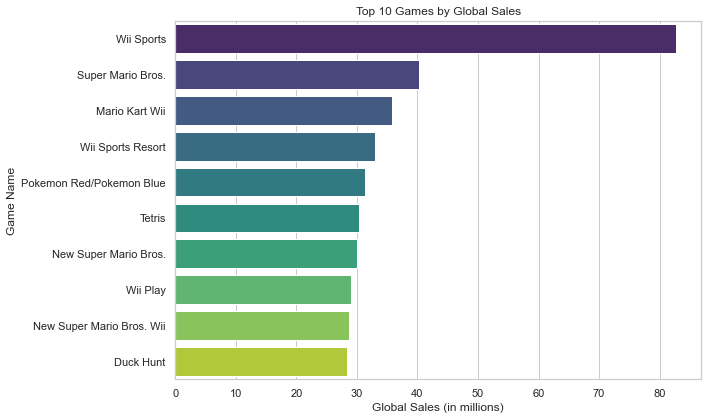

In [24]:
# Create a horizontal bar plot using Seaborn
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")  # Set the style, optional

sns.barplot(x='Global_Sales', y='Name', data=Top_10_games, palette='viridis')

# Set plot labels and title
plt.xlabel('Global Sales (in millions)')
plt.ylabel('Game Name')
plt.title('Top 10 Games by Global Sales')

# Display the plot
plt.tight_layout()
plt.show()

In [25]:
# WHAT IS THE MOST SOUGHT AFTER GENRE GLOBALLY 

Highest_genre_global_sales = df_video_game.groupby('Genre')[['Global_Sales']].sum().reset_index()

# rename column for clarity
Highest_genre_global_sales.columns = ['Genre', 'Total_Global_Sales']

Highest_genre_global_sales = Highest_genre_global_sales.sort_values('Total_Global_Sales', ascending=True)
Highest_genre_global_sales.iloc[:]

,Genre,Total_Global_Sales
11,Strategy,173.27
1,Adventure,234.59
5,Puzzle,242.21
9,Simulation,389.98
2,Fighting,444.05
6,Racing,726.76
3,Misc,789.87
4,Platform,829.13
7,Role-Playing,923.83
8,Shooter,1026.20


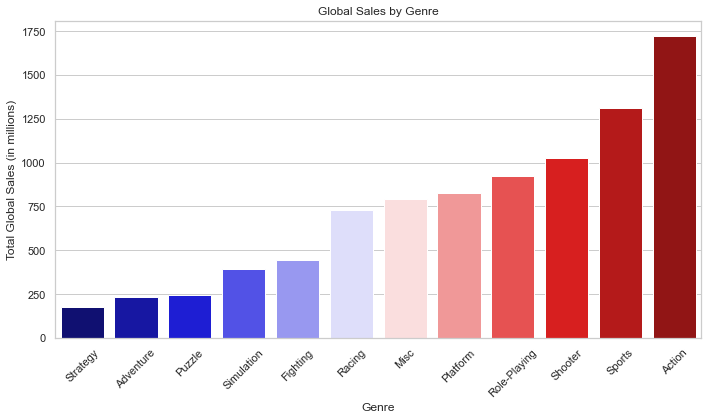

In [26]:
# Create a vertical bar plot using Seaborn
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")  # Set the style, optional

sns.barplot(x='Genre', y='Total_Global_Sales', data=Highest_genre_global_sales, palette='seismic')

# Set plot labels and title
plt.xlabel('Genre')
plt.ylabel('Total Global Sales (in millions)')
plt.title('Global Sales by Genre')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display the plot
plt.tight_layout()
plt.show()

In [27]:
 # DISTRIBUTION OF GENRE VIDEO GAMES ACROSS ALL REGIONS
    
df_video_game['Genre'].unique() # check for unique genre

array(['Sports', 'Platform', 'Racing', 'Role-Playing', 'Puzzle', 'Misc',
       'Shooter', 'Simulation', 'Action', 'Fighting', 'Adventure',
       'Strategy'], dtype=object)

In [28]:
genre_vid_distribution = df_video_game['Genre'].value_counts()
genre_vid_distribution

Action          3251
Sports          2304
Misc            1686
Role-Playing    1470
Shooter         1282
Adventure       1274
Racing          1225
Platform         875
Simulation       848
Fighting         836
Strategy         670
Puzzle           570
Name: Genre, dtype: int64

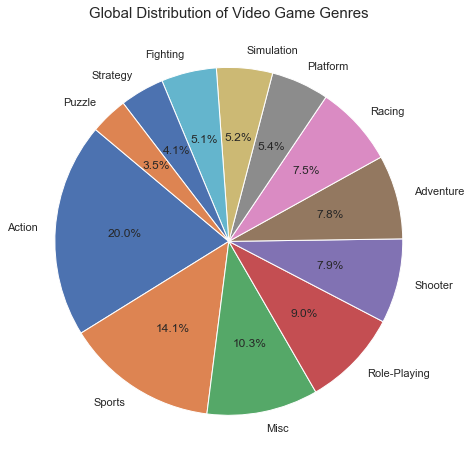

In [29]:
# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(genre_vid_distribution, labels=genre_vid_distribution.index, autopct='%1.1f%%', startangle=140)

# Set title
plt.title('Global Distribution of Video Game Genres', fontsize=15)

# Display the pie chart
plt.show()


In [30]:
# DO YOU NOTICE ANY REGIONAL DIFFERENCES IN GENRE PREFERENCE AND SALES PATTERN?

genre_sales_in_all_regions = df_video_game.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].sum().reset_index()

# rename columns for clarity
genre_sales_in_all_regions.columns = ['Genre', 'Total_NA_Sales', 'Total_EU_Sales', 'Total_JP_Sales', 'Total_Other_Sales','Total_Global_Sales']
genre_sales_in_all_regions

,Genre,Total_NA_Sales,Total_EU_Sales,Total_JP_Sales,Total_Other_Sales,Total_Global_Sales
0,Action,861.77,516.48,158.65,184.92,1722.84
1,Adventure,101.93,63.74,51.99,16.70,234.59
2,Fighting,220.74,100.00,87.15,36.19,444.05
3,Misc,396.92,211.77,106.67,73.92,789.87
4,Platform,445.99,200.65,130.65,51.51,829.13
5,Puzzle,122.01,50.52,56.68,12.47,242.21
6,Racing,356.93,236.31,56.61,76.68,726.76
7,Role-Playing,326.50,187.57,350.29,59.38,923.83
8,Shooter,575.16,310.45,38.18,101.90,1026.20
9,Simulation,181.78,113.02,63.54,31.36,389.98


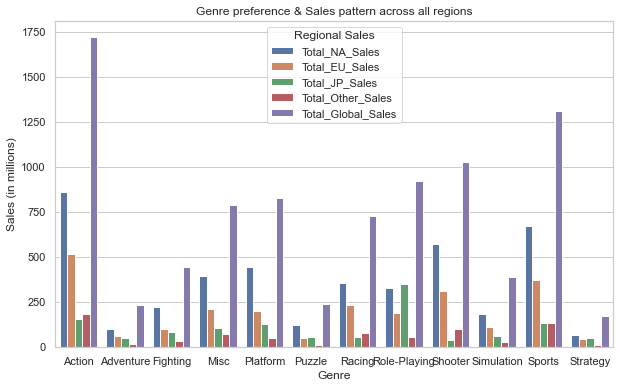

In [31]:
# Reshape the data using pd.melt
melted_data = pd.melt(
    genre_sales_in_all_regions,
    id_vars=['Genre'],
    value_vars=['Total_NA_Sales', 'Total_EU_Sales', 'Total_JP_Sales', 'Total_Other_Sales', 'Total_Global_Sales'],
    var_name='Region',
    value_name='Sales (in millions)'
)

plt.figure(figsize=(10, 6))

# Using Seaborn to create the stacked line plot
sns.barplot(
    x='Genre',
    y='Sales (in millions)',
    hue='Region',
    data=melted_data,
    ci=None  # To remove confidence intervals
)

# Set plot labels, legend and title
plt.xlabel('Genre')
plt.ylabel('Sales (in millions)')
plt.title('Genre preference & Sales pattern across all regions')
plt.legend(title='Regional Sales')
plt.show()

In [32]:
# ARE THERE ANY NOTICEABLE TREND OR PATTERNS IN NORTH AMERICAN SALES AND GLOBAL GAMES SALES OVER THE YEARS?

global_sales_yearly_trend = df_video_game.groupby('Year')[['NA_Sales','Global_Sales']].sum().reset_index()

# rename columns for clarity
global_sales_yearly_trend.columns = ['Year', 'Total_NA_Sales','Total_Global_Sales']
global_sales_yearly_trend = global_sales_yearly_trend.sort_values('Year', ascending = False)
global_sales_yearly_trend

,Year,Total_NA_Sales,Total_Global_Sales
38,2020.0,0.27,0.29
37,2017.0,0.00,0.05
36,2016.0,22.66,70.90
35,2015.0,102.82,264.44
34,2014.0,131.97,337.03
33,2013.0,154.77,368.11
32,2012.0,154.93,363.49
31,2011.0,241.00,515.80
30,2010.0,304.24,600.29
29,2009.0,338.85,667.30


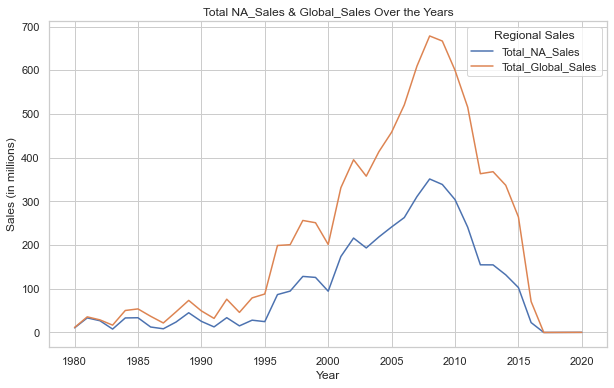

In [33]:
# Reshape the data using pd.melt
melted_data = pd.melt(
    global_sales_yearly_trend,
    id_vars=['Year'],
    value_vars=['Total_NA_Sales', 'Total_Global_Sales'],
    var_name='Region',
    value_name='Sales (in millions)'
)

plt.figure(figsize=(10, 6))

# Using Seaborn to create the stacked line plot
sns.lineplot(
    x='Year',
    y='Sales (in millions)',
    hue='Region',
    data=melted_data,
    ci=None  # To remove confidence intervals
)

# Set plot labels, legend and title
plt.xlabel('Year')
plt.ylabel('Sales (in millions)')
plt.title('Total NA_Sales & Global_Sales Over the Years')
plt.legend(title='Regional Sales')
plt.show()
